In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set a professional style
sns.set_theme(style="whitegrid") # Clean white background with grids

In [6]:
df4 = pd.read_csv('../output/gpu_topo_4_ranks_v3.csv')
df16= pd.read_csv('../output/gpu_topo_16_ranks_v3.csv')
df4.head()

,solver,nprocs,topology,nx_global,ny_global,nx_local,ny_local,nt,run,walltime,steps_per_second,cell_updates_per_second
0,manual,4,4x1,16386,4098,4098,4098,100,1,0.656073,152.422114,1.023512e+10
1,manual,4,4x1,16386,4098,4098,4098,100,2,0.656540,152.313534,1.022783e+10
2,manual,4,4x1,16386,4098,4098,4098,100,3,0.658394,151.884720,1.019903e+10
3,manual,4,4x1,16386,4098,4098,4098,100,4,0.655550,152.543752,1.024329e+10
4,manual,4,4x1,16386,4098,4098,4098,100,5,0.655466,152.563136,1.024459e+10


In [7]:
def upper_th(df, th=1): 
    keep = df.loc[df['walltime'] < th]
    return keep

def plot_performance(df): 
    plt.figure(figsize=(12, 7))   
    ax = sns.boxplot(
        data=df, 
        x='topology',            # Topologies on X-axis
        y='walltime',       # Walltime on Y-axis
        palette='viridis',   # Use a beautiful color gradient
        hue='topology',         # Assign color based on topology
        legend=False,       # Hide legend since X-axis already tells us the labels
        linewidth=2,        # Make the box lines slightly thicker
        fliersize=4         # Make outlier dots smaller/cleaner
    )

    # 3. Add a "Strip Plot" (optional but looks great)
    # This adds the individual data points over the boxes for transparency
    sns.stripplot(
        data=df, 
        x='topology', 
        y='walltime', 
        color='black', 
        alpha=0.3,           # Make dots semi-transparent
        jitter=True          # Spread dots out so they don't overlap
    )

    # 4. Polish the labels and titles
    plt.title('Performance Comparison Across domain Topologies', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Rank Decomposition Topology', fontsize=14, labelpad=10)
    plt.ylabel('Walltime (seconds)', fontsize=14, labelpad=10)
    plt.show()

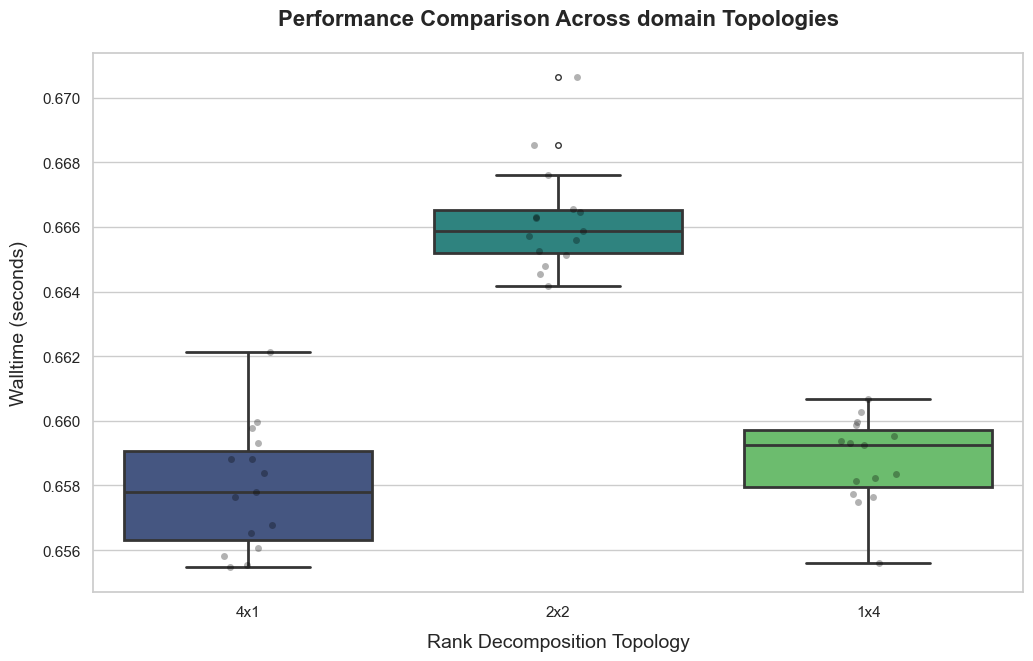

In [8]:
plot_performance(upper_th(df4))

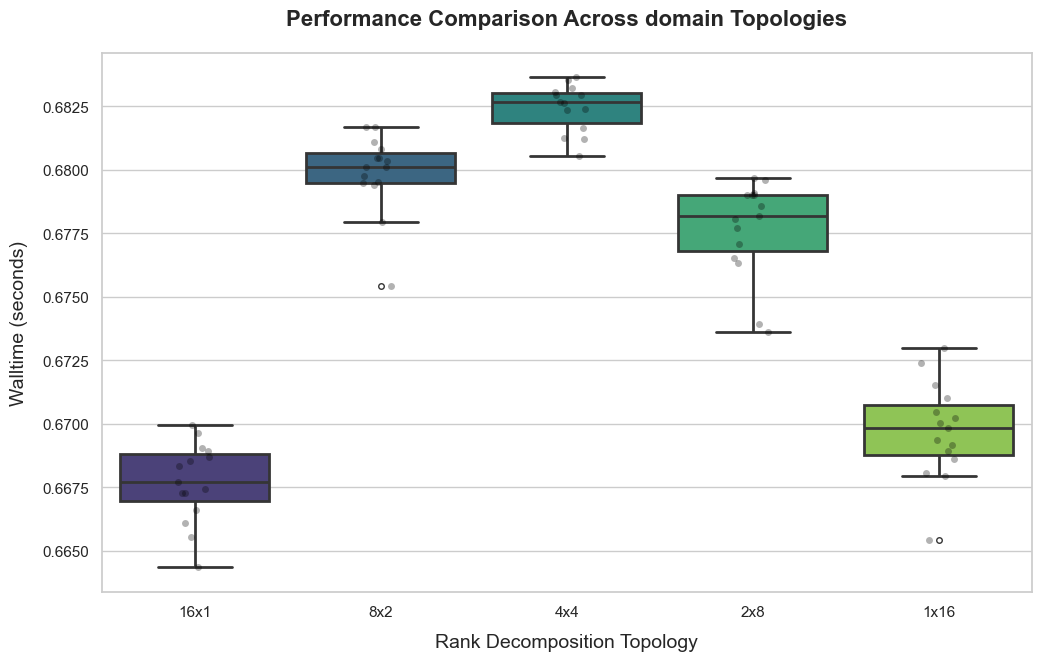

In [9]:
plot_performance(upper_th(df16, 0.7))